# PROJECT ASSIGNMENT: From Poetry to Production

## Trend Analysis of Lyrical Simplification and the "Industrialization" of Popular Music (1959 – 2023)

- **Student:** Vilibald Kovač
- **University:** Juraj Dobrila University of Pula (UNIPU)
- **Program:** Online Bachelor’s in IT
- **Course:** Introduction to Data Science
- **Date:** January 2026

---

## **1. Introduction and Motivation**

Popular music is often criticized for becoming increasingly simple and industrialized over time. This is reflected not only by repetitive musical structures but also in a visible decline in the complexity and subjective depth of song lyrics. Supporting the industrialization thesis is the fact that today, seemingly simple lyrical structures often have five or more credited co-writers.

This project explores this perspective through two key lenses:
* **The Phenomenon of Authorship Industrialization** – Testing the hypothesis that the number of writers per song has systematically increased over the years, indicating a shift toward an industrialized production process.
* **Time-Series Trend Analysis** – Using quantitative data to determine whether the lyrical complexity of hit songs has truly declined across decades, despite the increasing number of writers.

The goal is to provide empirical evidence supporting or refuting popular claims about the evolution of pop music, using available data and statistical methods.

---

## 2. Data (Dataset)

The dataset used is **"[Top 100 Songs & Lyrics By Year 1959 – 2023 (USA)](https://www.kaggle.com/datasets/brianblakely/top-100-songs-and-lyrics-from-1959-to-2019)"** downloaded from Kaggle (the URL says 2019, but the dataset on Kaggle has been updated through 2023).

The dataset contains the **top 100 songs** in the **USA** from 1959 to 2023 and includes:
* **Metadata:** song title, artist, release year, chart position (Rank).
* **Content:** full text of the songs (Lyrics).
* **Authors:** a list of all credited writers for the song (Writers).

---

## 3. Analysis Approach

To measure lexical diversity, I chose to use TTR.

[Type–Token Ratio (TTR)](https://medium.com/@rajeswaridepala/empirical-laws-ttr-cc9f826d304d) is a quantitative measure of lexical diversity defined as the ratio of the number of unique words to the total number of words in a text.

$$TTR = \frac{\text{Number of Unique Words (Types)}}{\text{Total Number of Words (Tokens)}}$$

The TTR value ranges from 0 to 1:
* **TTR close to 1:** Every word in the text is unique.
* **TTR close to 0:** The text contains a high amount of word repetition.
* **TTR of 0.5:** Half of the words in the text are unique, and half are repeated.

### Why TTR?

Although TTR could show the simplification trend, its main limitation must be kept in mind: its dependence on text length. As the total word count increases, TTR tends to decrease because longer texts are more likely to contain repeated words. This is particularly relevant for song lyrics, which can vary widely in length.
A potential implementation of metrics like MTLD ([Measure of Textual Lexical Diversity](https://search.r-project.org/CRAN/refmans/koRpus/html/MTLD.html)) — although there are indications it is more suitable for long novels than short texts — or [Shannon Entropy](https://thesagardahal.medium.com/understanding-shannon-entropy-measuring-randomness-for-secure-code-auditing-4b3c5697a7f9), would be necessary to confirm the hypothesis in a broader, academic study.
However, for the scope of this project, TTR was selected as a sufficiently precise metric that is simultaneously clearer and more intuitive (it is easier to conceptualize and present than, for example, Shannon Entropy). 

The analysis will simultaneously track the total word count to better understand the differences between shorter and longer songs, and texts with extremely small or large word counts will be filtered out.

The objective is to calculate the TTR for each song in the dataset and then analyze the trends across decades of popular music. I expect that TTR will decrease over time, which would indicate a simplification of vocabulary in popular music.

## ⚠️ Additional Model Limitations (Key for Interpretation)

1. **Inability to Classify Structure:** This model treats the song lyrics as a single bag of words. It does not recognize song parts such as the **verse**, **chorus**, or **hook**. Since most repetitiveness in pop music occurs specifically in the repetition of the chorus, a more rigorous analysis would need to measure these parts separately.
2. **Broad Definition of Authors:** Under the "Writers" column, the database credits everyone who contributed to the song. This often can include producers, beatmakers, or sample creators; the list is likely not limited strictly to lyricists. Therefore, the "number of writers" here actually represents the **size of the production team**.
3. **Quantity vs. Quality:** The analysis measures lexical complexity (TTR), but this is not a direct measure of the artistic quality of the lyrics.

**Despite these limitations, I believe the data across such a large sample size will clearly show whether a trend of music industrialization exists and how it has evolved over the decades.**

---



## Libraries and Data Frame Import

In [27]:
# libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # for better visualization
         

In [28]:
# importing the data frame
df = pd.read_csv('all_songs_data.csv')
print('Table Structure:\n')
df.head(5)



Table Structure:



,Album,Album URL,Artist,Featured Artists,Lyrics,Media,Rank,Release Date,Song Title,Song URL,Writers,Year
0,Battle of New Orleans,https://genius.com/albums/Johnny-horton/Battle...,Johnny Horton,[],[Verse 1] In 1814 we took a little trip Along ...,[{'native_uri': 'spotify:track:0dwpdcQkeZqpuoA...,1,1959-04-01,The Battle Of New Orleans,https://genius.com/Johnny-horton-the-battle-of...,"[{'api_path': '/artists/561913', 'header_image...",1959.0
1,That’s All,https://genius.com/albums/Bobby-darin/That-s-all,Bobby Darin,[],"Oh the shark, babe Has such teeth, dear And he...",[{'native_uri': 'spotify:track:3E5ndyOfO6vFDEI...,2,NaN,Mack The Knife,https://genius.com/Bobby-darin-mack-the-knife-...,"[{'api_path': '/artists/218851', 'header_image...",1959.0
2,“Mr Personality’s” 15 Big Hits,https://genius.com/albums/Lloyd-price/Mr-perso...,Lloyd Price,[],Over and over I tried to prove my love to you ...,"[{'provider': 'youtube', 'start': 0, 'type': '...",3,NaN,Personality,https://genius.com/Lloyd-price-personality-lyrics,"[{'api_path': '/artists/355804', 'header_image...",1959.0
3,The Greatest Hits Of Frankie Avalon,https://genius.com/albums/Frankie-avalon/The-g...,Frankie Avalon,[],"Hey, Venus! Oh, Venus! Venus, if you will Ple...",[],4,NaN,Venus,https://genius.com/Frankie-avalon-venus-lyrics,"[{'api_path': '/artists/1113175', 'header_imag...",1959.0
4,Paul Anka Sings His Big 15,https://genius.com/albums/Paul-anka/Paul-anka-...,Paul Anka,[],I'm just a lonely boy Lonely and blue I'm all ...,[],5,NaN,Lonely Boy,https://genius.com/Paul-anka-lonely-boy-lyrics,[],1959.0


In [29]:
df.shape

(6500, 12)

## Data Cleaning and Preprocessing

### Data Cleaning Steps

In [30]:
# Number of songs before cleaning
initialSongCount = len(df)

# Dropping columns that are not relevant for our analysis
df = df.drop(
    columns=["Album", "Album URL", "Featured Artists", "Media", "Release Date", "Song URL"],
    errors="ignore"
)

# Removing rows missing Lyrics or Writers (incomplete records)
df = df.dropna(subset=["Lyrics", "Writers"])

# Filtering out rows where Lyrics or Writers are empty lists
df = df[df["Lyrics"] != "[]"]
df = df[df["Writers"] != "[]"]

# Number of songs after cleaning
finalSongCount = len(df)
deletedRowsCount = initialSongCount - finalSongCount

print(f"Total invalid rows removed: {deletedRowsCount}")
print(f"Number of songs remaining for analysis: {finalSongCount}")

df.head(5)

Total invalid rows removed: 1087
Number of songs remaining for analysis: 5413


,Artist,Lyrics,Rank,Song Title,Writers,Year
0,Johnny Horton,[Verse 1] In 1814 we took a little trip Along ...,1,The Battle Of New Orleans,"[{'api_path': '/artists/561913', 'header_image...",1959.0
1,Bobby Darin,"Oh the shark, babe Has such teeth, dear And he...",2,Mack The Knife,"[{'api_path': '/artists/218851', 'header_image...",1959.0
2,Lloyd Price,Over and over I tried to prove my love to you ...,3,Personality,"[{'api_path': '/artists/355804', 'header_image...",1959.0
3,Frankie Avalon,"Hey, Venus! Oh, Venus! Venus, if you will Ple...",4,Venus,"[{'api_path': '/artists/1113175', 'header_imag...",1959.0
5,Bobby Darin,[Verse 1] Every night I hope and pray A dream ...,6,Dream Lover,"[{'api_path': '/artists/115571', 'header_image...",1959.0


## Cleaning the column Writers

In the `Writers` column we have too many metadata fields that we don't need. Therefore, this piece of code is used to separate this data into two clear columns:
- Writer List: only with the names of the song authors.
- Writer Count: the number of signed authors per song.

In [31]:
# example of the content
display(df["Writers"][0])

"[{'api_path': '/artists/561913', 'header_image_url': 'https://images.genius.com/641ca05661977b0309ebffc9507f2baf.202x202x1.jpg', 'id': 561913, 'image_url': 'https://images.genius.com/641ca05661977b0309ebffc9507f2baf.202x202x1.jpg', 'is_meme_verified': False, 'is_verified': False, 'name': 'Jimmy Driftwood', 'url': 'https://genius.com/artists/Jimmy-driftwood'}]"

In [32]:
# filtering Writers data

# Creating a list to be added to the main dataframe 
allWriterLists = []

for entry in df["Writers"]:
    # Splitting the string to isolate the 'name' field
    parts = str(entry).split("'name': '")
    
    songAuthors = []
    
    for author in parts[1:]:
        # Cleaning the string to extract only the name
        splitting = author.split("',")
        name = splitting[0]
        songAuthors.append(name)
    
    allWriterLists.append(songAuthors)
    
# Creating new columns
df["Writer List"] = allWriterLists
df["Writer Count"] = df["Writer List"].apply(len)

# Dropping the original 'Writers' column
df = df.drop(columns=["Writers"])

df.head(5)

,Artist,Lyrics,Rank,Song Title,Year,Writer List,Writer Count
0,Johnny Horton,[Verse 1] In 1814 we took a little trip Along ...,1,The Battle Of New Orleans,1959.0,[Jimmy Driftwood],1
1,Bobby Darin,"Oh the shark, babe Has such teeth, dear And he...",2,Mack The Knife,1959.0,"[Kurt Weill, Bertolt Brecht]",2
2,Lloyd Price,Over and over I tried to prove my love to you ...,3,Personality,1959.0,"[Lloyd Price, Harold Logan]",2
3,Frankie Avalon,"Hey, Venus! Oh, Venus! Venus, if you will Ple...",4,Venus,1959.0,"[Ed Marshall, Peter de Angelis]",2
5,Bobby Darin,[Verse 1] Every night I hope and pray A dream ...,6,Dream Lover,1959.0,[Bobby Darin],1


### Cleaning the text in the Lyrics column
- Cleaning the text in the 'Lyrics' column by removing brackets and labels of song parts like [Verse], [Chorus], [Bridge] and similar, as these words are not part of the song text but metadata.

In [33]:
# CLEANING THE LYRICS COLUMN

def cleanText(text):
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Split text to handle metadata tags
    segments = text.split("[")
    cleanTextContent = ""

    # Removing [Chorus], [Verse], etc.
    for segment in segments:
        if "]" in segment:
            tempSplit = segment.split("]")
            textWithoutBracket = tempSplit[1]
            cleanTextContent += textWithoutBracket
        else:
            cleanTextContent += segment
            
    # Remove apostrophes entirely so "haven't" becomes "havent"
    # This prevents "haven't" from being split into "haven" and "t"
    cleanTextContent = cleanTextContent.replace("'", "")

    # Removing other punctuation marks and replacing with a space
    # (Notice I removed "'" from the list below)
    punctuationToRemove = [",", ".", "!", "?", ":", ";", "(", ")", "\"", "-", "_", "/"]
    for mark in punctuationToRemove:
        cleanTextContent = cleanTextContent.replace(mark, " ")

    # Remove multiple spaces and trim edges
    cleanTextContent = " ".join(cleanTextContent.split())
    
    return cleanTextContent

# Applying the function
df["Lyrics"] = df["Lyrics"].apply(cleanText)
df = df.reset_index(drop=True)

df.head(5)

,Artist,Lyrics,Rank,Song Title,Year,Writer List,Writer Count
0,Johnny Horton,in 1814 we took a little trip along with colon...,1,The Battle Of New Orleans,1959.0,[Jimmy Driftwood],1
1,Bobby Darin,oh the shark babe has such teeth dear and he s...,2,Mack The Knife,1959.0,"[Kurt Weill, Bertolt Brecht]",2
2,Lloyd Price,over and over i tried to prove my love to you ...,3,Personality,1959.0,"[Lloyd Price, Harold Logan]",2
3,Frankie Avalon,hey venus oh venus venus if you will please se...,4,Venus,1959.0,"[Ed Marshall, Peter de Angelis]",2
4,Bobby Darin,every night i hope and pray a dream lover will...,6,Dream Lover,1959.0,[Bobby Darin],1


In [34]:
#example of cleaned lyrics

print(df["Lyrics"][0])

in 1814 we took a little trip along with colonel jackson down the mighty mississip we took a little bacon and we took a little beans and we caught the bloody british in a town near new orleans we fired our guns and the british kept a comin there wasnt nigh as many as there was a while ago we fired once more and they begin to runnin on down the mississippi to the gulf of mexico we looked down a river hut two and we seed the british come three four and there must have been a hundred ofem hut two beatin on the drums three four they stepped so high hut two and they made their bugles ring three four we stood beside our cotton bales hut two and didnt say a thing two three four we fired our guns and the british kept a comin there wasnt nigh as many as there was a while ago we fired once more and they begin to runnin on down the mississippi to the gulf of mexico old hickory said we could take em by surprise one hut two three four if we didnt fire our muskets one hut two three four till we look

### Add column for decades
Adding a 'decade' column to facilitate easier categorization of trends across decades


In [35]:

df['Decade'] = (df['Year'] // 10) * 10
df['Decade'] = df['Decade'].astype(int)

# quick overview
df.head(5)

,Artist,Lyrics,Rank,Song Title,Year,Writer List,Writer Count,Decade
0,Johnny Horton,in 1814 we took a little trip along with colon...,1,The Battle Of New Orleans,1959.0,[Jimmy Driftwood],1,1950
1,Bobby Darin,oh the shark babe has such teeth dear and he s...,2,Mack The Knife,1959.0,"[Kurt Weill, Bertolt Brecht]",2,1950
2,Lloyd Price,over and over i tried to prove my love to you ...,3,Personality,1959.0,"[Lloyd Price, Harold Logan]",2,1950
3,Frankie Avalon,hey venus oh venus venus if you will please se...,4,Venus,1959.0,"[Ed Marshall, Peter de Angelis]",2,1950
4,Bobby Darin,every night i hope and pray a dream lover will...,6,Dream Lover,1959.0,[Bobby Darin],1,1950


## Additional preparation for analysis

### Lexical Complexity (TTR)



In [36]:
# TTR Algorithm
def calculateTTR(text):
    
    # Convert to string and split into words by spaces
    words = str(text).split()
    
    # If there are no words, TTR is 0.0
    if len(words) == 0:
        return 0.0
    
    # Create a set of unique words
    uniqueWords = set(words)
    
    # Calculate Type-Token Ratio (TTR)
    ttrValue = len(uniqueWords) / len(words)
    
    return ttrValue

# Function for counting the total number of words
def countWords(text):
    
    wordCounter = 0
    
    for word in str(text).split():
        wordCounter += 1
    
    return wordCounter

# Applying calculations to the dataframe
df["WordCount"] = df["Lyrics"].apply(countWords)
df["TTR"] = df["Lyrics"].apply(calculateTTR)

df.head(5)

,Artist,Lyrics,Rank,Song Title,Year,Writer List,Writer Count,Decade,WordCount,TTR
0,Johnny Horton,in 1814 we took a little trip along with colon...,1,The Battle Of New Orleans,1959.0,[Jimmy Driftwood],1,1950,488,0.284836
1,Bobby Darin,oh the shark babe has such teeth dear and he s...,2,Mack The Knife,1959.0,"[Kurt Weill, Bertolt Brecht]",2,1950,224,0.571429
2,Lloyd Price,over and over i tried to prove my love to you ...,3,Personality,1959.0,"[Lloyd Price, Harold Logan]",2,1950,215,0.223256
3,Frankie Avalon,hey venus oh venus venus if you will please se...,4,Venus,1959.0,"[Ed Marshall, Peter de Angelis]",2,1950,166,0.415663
4,Bobby Darin,every night i hope and pray a dream lover will...,6,Dream Lover,1959.0,[Bobby Darin],1,1950,275,0.272727


### Filtering Outliers

Before calculating the average TTR by decade, the dataset must be cleaned of duplicates and extremes to ensure an accurate analysis.
- **Chronological De-duplication:** The dataset is sorted by Year, retaining only the first instance of each song. This ensures a track's lyrical complexity is attributed to its original release era, preventing modern chart re-entries from skewing historical trends.
- **Removing Extremes:** Statistical outliers (such as very short interludes or excessively long tracks) are filtered out to focus on standard song structures. Based on the dataset's statistical distribution, the analysis is restricted to tracks within the 150 to 800 word range.

In [37]:

# To preserve historical accuracy, we keep only the first time a song appears.

countBefore = len(df)

# Sort by Year (ascending) to ensure the earliest release comes first
df = df.sort_values('Year', ascending=True)

# Drop duplicates based on Song Title and Artist, keeping only the 'first' (earliest)
df = df.drop_duplicates(subset=['Song Title', 'Artist'], keep='first')

removedDuplicates = countBefore - len(df)

print(f"De-duplication Complete:")
print(f"- Removed {removedDuplicates} chart re-entries.")
print(f"- Unique songs remaining for analysis: {len(df)}")

De-duplication Complete:
- Removed 255 chart re-entries.
- Unique songs remaining for analysis: 5158


In [38]:
# --- STEP 2: DATA DIAGNOSTICS (Establishing Boundaries) ---
# We calculate statistics based ONLY on unique songs to avoid bias.

print("Word Count Statistics (Unique Songs Only):")
display(df['WordCount'].describe())

# Identifying the 5th, 50th (Median), and 95th percentiles
quantiles = df['WordCount'].quantile([0.05, 0.50, 0.95])

print("\n--- Outlier Detection Analysis ---")
print(f"Bottom 5% (Shortest tracks/intros): {quantiles[0.05]:.0f} words")
print(f"50% of songs (Median word count):   {quantiles[0.50]:.0f} words")
print(f"Top 5% (Longest/experimental tracks): {quantiles[0.95]:.0f} words")

# This data justifies the 150-800 word filter used in the next phase.

Word Count Statistics (Unique Songs Only):


count     5158.000000
mean       382.978286
std        537.922066
min          0.000000
25%        233.000000
50%        321.000000
75%        450.000000
max      22669.000000
Name: WordCount, dtype: float64


--- Outlier Detection Analysis ---
Bottom 5% (Shortest tracks/intros): 142 words
50% of songs (Median word count):   321 words
Top 5% (Longest/experimental tracks): 739 words


This step removes the bottom 5% and top 4% of the data. This creates a more stable sample for calculating TTR, while still keeping the dataset large enough for a reliable analysis.

In [39]:
# 1. Store the song count before cleaning
countBefore = len(df)

# 2. Apply word count filter (between 150 and 800 words)
df = df[(df["WordCount"] >= 150) & (df["WordCount"] <= 800)].copy()

# 3. Reset indices immediately
df = df.reset_index(drop=True)

# 4. Calculate how many records were removed
removedCount = countBefore - len(df)

print(f"Removed {removedCount} songs identified as outliers.")
print(f"Final count for analysis: {len(df)} songs.")
print(f"New average word count: {df['WordCount'].mean():.2f}")

Removed 475 songs identified as outliers.
Final count for analysis: 4683 songs.
New average word count: 360.39


In [40]:
# appliing TTR calculation after filtering
df["TTR"] = df["Lyrics"].apply(calculateTTR)
df.head(5)

,Artist,Lyrics,Rank,Song Title,Year,Writer List,Writer Count,Decade,WordCount,TTR
0,Johnny Horton,in 1814 we took a little trip along with colon...,1,The Battle Of New Orleans,1959.0,[Jimmy Driftwood],1,1950,488,0.284836
1,Ray Charles,hey mama dont you treat me wrong come and love...,50,What'd I Say,1959.0,[Ray Charles],1,1950,567,0.162257
2,Coasters,she comes on like a rose but everybody knows s...,54,Poison Ivy,1959.0,"[Jerry Leiber, Mike Stoller]",2,1950,242,0.334711
3,Jackie Wilson,shooby doo wop ba baa hey hey shooby doo wop b...,56,Lonely Teardrops,1959.0,"[Gwendolyn Gordy, Roquel “Billy” Davis, Berry ...",3,1950,189,0.291005
4,Elvis Presley,now and then theres a fool such as i pardon me...,34,(Now And Then There's) A Fool Such As I,1959.0,[Bill Trader],1,1950,162,0.302469


## Analysis

### Increase in the Number of Authors Over Decades

To explore the "industrialization" of songwriting, the first step is to track the average number of credited authors per song over time. This helps determine if the industry has gradually shifted toward a team-based model.

As the graph shows, there is a clear upward trend, with a significant spike beginning in the 1990s. This shift in the mid-90s shows a strong industrialization of music. Instead of single songwriters, entire teams of producers and lyricists began collaborating on individual tracks to maximize commercial potential and ensure chart success.

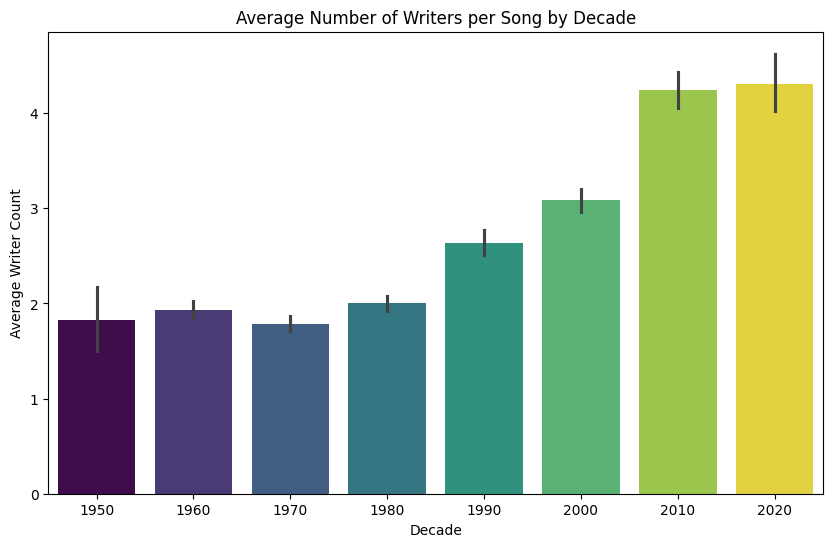

In [41]:
# Number of writers over time: average writers per decade (Bar Plot)
plt.figure(figsize=(10, 6))

# Plotting the data
sns.barplot(data=df, x='Decade', y='Writer Count', palette='viridis', hue='Decade', legend=False)

# Adding professional labels and title
plt.title('Average Number of Writers per Song by Decade')
plt.xlabel('Decade')
plt.ylabel('Average Writer Count')

plt.show()

Vertical black lines in the graph (error bars) show the **variation** in the data:
* **1950s (High uncertainty):** We see a long line, meaning a large variation in the data, but for this decade we have the least data (the dataset starts only from 1959).
* **1970s and 1980s (Stability of songwriters):** The lines are very short. This means the situation was stable — most songs had a similar, very small number of authors. The creative process was uniform.
* **2010s and 2020s (Industrial chaos):** The lines increase dramatically again. Although the average number of authors is about double what it was in the 80s (over 4 authors), the large variation tells us that the market is polarized: today we have hits that are still written by two people, but also those with 10 or more authors (we should note that for the 2020s we still don't have enough data because we have information up to 2023).

**The increase in variation over the last two decades proves that the standard "single author" has disappeared. Modern production has no rules — songs become the result of mass teams.**

In [42]:
# Number of songs analyzed per decade
songsPerDecade = df.groupby('Decade').size()

print("Song count per decade:")
print(songsPerDecade)

Song count per decade:
Decade
1950     28
1960    475
1970    684
1980    797
1990    780
2000    793
2010    808
2020    318
dtype: int64


In [43]:
# Fun Fact / Potential Presentation Highlight

# Finding the 10 songs with the highest writer count and displaying key metrics
authorshipRecords = df.nlargest(10, 'Writer Count')[['Song Title', 'Artist', 'Year', 'Writer Count', 'WordCount', 'TTR']]

print("Top 10 songs with the largest songwriting teams and their metrics:")
display(authorshipRecords) # 'display' provides better formatting in Jupyter than 'print'

# Extracting data for the all-time record holder
topRecord = authorshipRecords.iloc[0]
songName = topRecord['Song Title']
artistName = topRecord['Artist']
writerCount = topRecord['Writer Count']
ttrValue = topRecord['TTR']

print(f"\nThe clear record holder: '{songName}' by {artistName} has {int(writerCount)} credited writers with a TTR of {ttrValue:.4f}.")

Top 10 songs with the largest songwriting teams and their metrics:


,Song Title,Artist,Year,Writer Count,WordCount,TTR
4272,Sicko Mode,Travis Scott,2018.0,30,780,0.401282
4069,All In My Head (Flex),Fifth Harmony feat. Fetty Wap,2016.0,23,447,0.241611
4218,Be Careful,Cardi B,2018.0,17,596,0.394295
3936,Timber,Pitbull feat. Ke$ha,2014.0,16,520,0.209615
4428,Go Crazy,Chris Brown and Young Thug,2020.0,16,577,0.275563
4668,Superhero (Heroes & Villains),"Metro Boomin, Future and Chris Brown",2023.0,16,581,0.382100
2455,I Got 5 On It,Luniz,1995.0,15,743,0.406460
4207,Strip That Down,Liam Payne Featuring Quavo,2017.0,15,716,0.238827
4257,Nice For What,Drake,2018.0,15,745,0.246980
4258,In My Feelings,Drake,2018.0,15,572,0.297203



The clear record holder: 'Sicko Mode' by Travis Scott has 30 credited writers with a TTR of 0.4013.


### Case study: Queen vs Taylor Swift 

Before analyzing lyrical complexity by decades, let us take two well-known songs that serve as contrasting examples.

- Queen – Bohemian Rhapsody (1975)
  -  even though this song is an "anomaly" in pop history (without a classic refrain, with operatic sections) it first came to mind as a song taht is expected to have higher lexical diversity.
  -   the song is signed by 1 author.
- Taylor Swift – Shake It Off (2014) 
  - a classic example of a modern hit, with a focus on rhythm and repetition of key words (hooks). 
  - the song is credited to 3 authors.


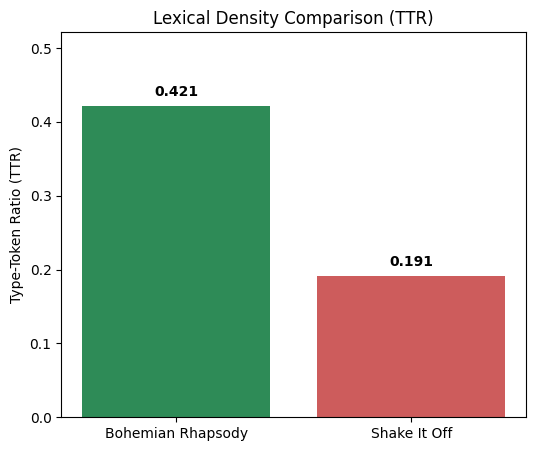

Bohemian Rhapsody -> Word Count: 375, TTR: 0.421
Writers: ['Freddie Mercury']
Shake It Off      -> Word Count: 598, TTR: 0.191
Writers: ['Shellback', 'Max Martin', 'Taylor Swift']


In [44]:
# Comparison of specific tracks
queenSong = df[(df['Song Title'].str.contains("Bohemian Rhapsody", case=False)) & 
                  (df['Artist'].str.contains("Queen", case=False))]

taylorSong = df[(df['Song Title'].str.contains("Shake It Off", case=False)) & 
                   (df['Artist'].str.contains("Taylor Swift", case=False))]

# Extracting TTR values 
qTTR = queenSong['TTR'].values[0]
tTTR = taylorSong['TTR'].values[0]

# Plotting the comparison
plt.figure(figsize=(6, 5))
plt.bar(['Bohemian Rhapsody', 'Shake It Off'], [qTTR, tTTR], color=['seagreen', 'indianred'])

# Adding values above the bars
plt.text(0, qTTR + 0.01, round(qTTR, 3), ha='center', va='bottom', fontweight='bold')
plt.text(1, tTTR + 0.01, round(tTTR, 3), ha='center', va='bottom', fontweight='bold')

plt.ylim(0, max(qTTR, tTTR) + 0.1)
plt.ylabel('Type-Token Ratio (TTR)')
plt.title('Lexical Density Comparison (TTR)')
plt.show()

# Performance Summary
qWC = len(str(queenSong['Lyrics'].values[0]).split())
tWC = len(str(taylorSong['Lyrics'].values[0]).split())

print(f"Bohemian Rhapsody -> Word Count: {qWC}, TTR: {round(qTTR, 3)}")
print(f"Writers: {queenSong['Writer List'].values[0]}")
print(f"Shake It Off      -> Word Count: {tWC}, TTR: {round(tTTR, 3)}")
print(f"Writers: {taylorSong['Writer List'].values[0]}")

### Case Study: Complexity vs. Repetition

**Is Queen's TTR higher just because the song has fewer words?** The answer is: **No.** TTR depends on how many *unique* words are used relative to the *total* word count.

| Song | Total Words (Denominator) | Unique Words (Numerator) | Calculation (TTR) |
| :--- | :---: | :---: | :---: |
| **Bohemian Rhapsody (1975)** | 375 | 158 | 158 / 375 = **0.421** |
| **Shake It Off (2014)** | 597 | 113 | 113 / 597 = **0.189** |

For *Shake It Off* to have the same lexical density (TTR) as *Bohemian Rhapsody*, with its 597 words, it would need to use about **251 different words**. Instead, it relies on only **113**.

**Conclusion:** Queen's high TTR is not a coincidence, but rather the result of a **structure without repetition**. Taylor Swift's track yields a lower score because it uses almost **60% more text** (larger denominator) while relying on a **28% poorer vocabulary** (smaller numerator). 

This highlights a fascinating shift in songwriting philosophy. While Freddie Mercury independently crafted a lyrically dense masterpiece in 6 minutes, modern algorithmic hits like *Shake It Off* often utilize a multi-person production team to produce text that is, mathematically speaking, more than twice as impoverished.

In [45]:
# Additional hand-picked songs for quick comparison in a presentation
# These iconic tracks serve as recognizable benchmarks for the analysis
keySongsFilter = 'Suspicious|Blinding|Levitating|Shape of You|Deep Is Your Love|Mind Set on You |Thriller|Uptown Funk|September|Set On You|Shake It Off|Bohemian Rhapsody|Imagine|Hey Jude|Smells Like Teen Spirit'

# Filtering the dataframe for these specific titles
comparisonTable = df[df['Song Title'].str.contains(keySongsFilter, case=False, na=False)]

# Displaying the results
print("Comparative analysis of iconic hits across different eras:")
display(comparisonTable[['Song Title', 'Artist', 'Year', 'WordCount', 'TTR', 'Writer Count']])

Comparative analysis of iconic hits across different eras:


,Song Title,Artist,Year,WordCount,TTR,Writer Count
321,See You In September,Happenings,1966.0,205,0.312195,2
423,Hey Jude,Beatles,1968.0,544,0.172794,2
490,Suspicious Minds,Elvis Presley,1969.0,274,0.288321,1
938,Bohemian Rhapsody,Queen,1976.0,375,0.421333,1
1091,How Deep Is Your Love,Bee Gees,1978.0,373,0.217158,3
1148,September,"Earth, Wind and Fire",1979.0,346,0.228324,3
1211,September Morn,Neil Diamond,1980.0,218,0.408257,2
1498,Thriller,Michael Jackson,1984.0,477,0.425577,1
1874,Got My Mind Set On You,George Harrison,1988.0,412,0.097087,1
2228,Smells Like Teen Spirit,Nirvana,1992.0,254,0.342520,3


### Lexical Diversity Across Decades

Analyzing lexical diversity (TTR) across decades, we visually track changes in text structure. Two graphs are displayed:
- **Left Graph:** Shows the relationship between the total number of words (blue line) and the number of unique words (orange line). This visualizes the ratio between the total word count and unique words in songs.

- **Right Graph:** Displays the movement of TTR values, i.e., the average lexical density across years. Black markers represent average values for each decade, while the horizontal dashed line indicates the overall average TTR for the entire dataset.

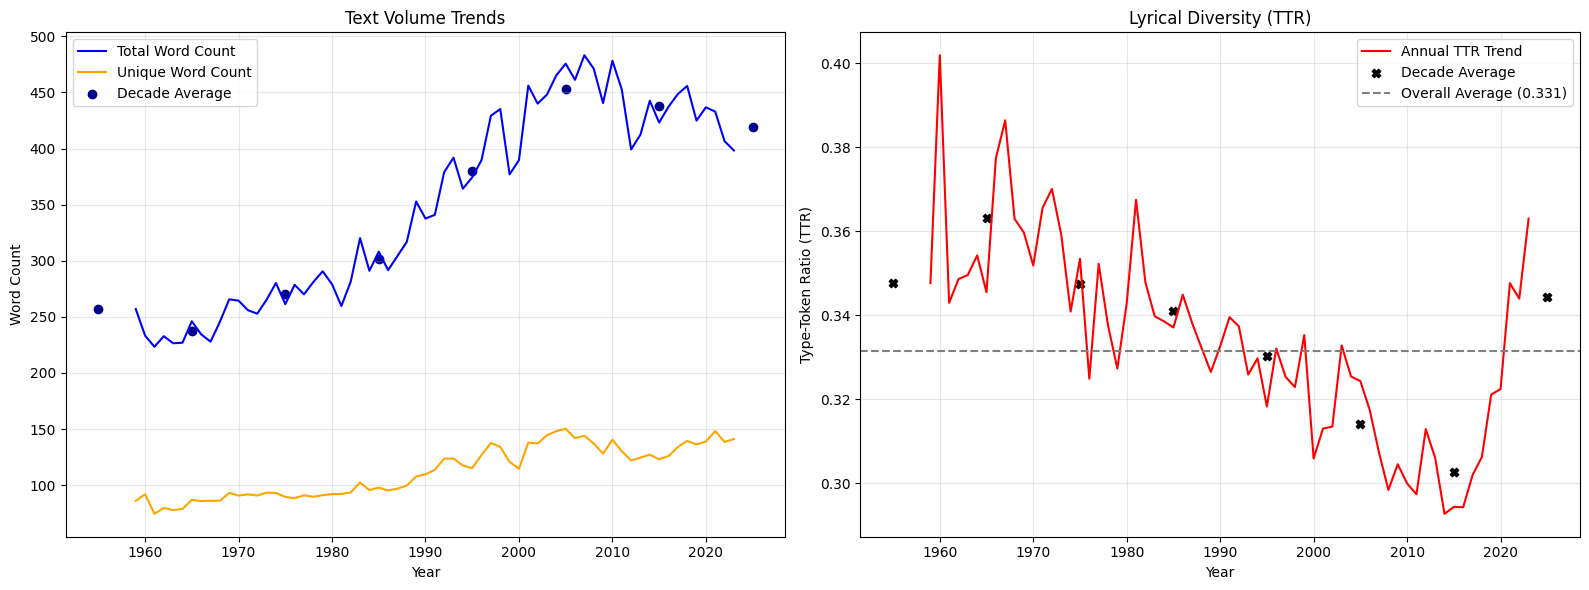

In [46]:
# Function for counting unique words
def countUniqueWords(text):
    words = str(text).split()
    unique = set(words)
    return len(unique)

# Creating the UniqueWords column
df["UniqueWords"] = df["Lyrics"].apply(countUniqueWords)

# Grouping by Year
yearlyStats = df.groupby('Year')[['WordCount', 'UniqueWords', 'TTR']].mean().reset_index()

# Grouping by Decade
decadeStats = df.groupby('Decade')[['WordCount', 'UniqueWords','TTR']].mean().reset_index()

# Creating mid-decade points for plotting accuracy
decadeStats['MidDecade'] = decadeStats['Decade'] + 5

plt.figure(figsize=(16,6))

# Left Plot: Text Volume
plt.subplot(1, 2, 1)
sns.lineplot(data=yearlyStats, x='Year', y='WordCount', color='blue', label='Total Word Count')
sns.lineplot(data=yearlyStats, x='Year', y='UniqueWords', color='orange', label='Unique Word Count')
plt.scatter(decadeStats['MidDecade'], decadeStats['WordCount'], color='darkblue', marker='o', label='Decade Average')

plt.xlabel('Year')
plt.ylabel('Word Count')
plt.grid(True, alpha=0.3)
plt.title('Text Volume Trends')
plt.legend()

# Right Plot: Lyrical Diversity
plt.subplot(1, 2, 2)
sns.lineplot(data=yearlyStats, x='Year', y='TTR', color='red', label='Annual TTR Trend')
plt.scatter(decadeStats['MidDecade'], decadeStats['TTR'], color='black', marker='X', label='Decade Average')

# Global average line
plt.axhline(y=df['TTR'].mean(), color='gray', linestyle='--', label=f'Overall Average ({df["TTR"].mean():.3f})')

plt.xlabel('Year')
plt.ylabel('Type-Token Ratio (TTR)')
plt.grid(True, alpha=0.3)
plt.title('Lyrical Diversity (TTR)')
plt.legend()

plt.tight_layout() 
plt.show()


## Visualizing the Industrialization of Pop

**Left Plot**: Text Volume Trends (The Repetition Gap) 
- In the 1960s, the blue line (Total Word Count) and orange line (Unique Word Count) track relatively close together, indicating shorter, more concise song structures.
- As we move toward the 2000s and 2010s, total word count increases dramatically, practically doubling in volume. However, the unique word count increases only slightly, remaining relatively flat.
- The widening visual gap between these two lines shows that modern songs contain significantly more lyrics, but those extra words are simply repeating the same vocabulary (e.g., extended choruses, repeated hooks).

**Right Plot**: Lyrical Diversity (The TTR Decline )
- This graph calculates the ratio between the two lines on the left. As demonstrated in the Bohemian Rhapsody vs. Shake It Off case study, when total words surge but unique words stagnate, the Type-Token Ratio (TTR) drops.
- The data reveals a steady decline in lyrical complexity from the 1960s through the 2010s, with recent decades dropping well below the historical overall average (0.334, the dashed grey line).
- Note on the 2020s: There appears to be a sharp reversal trend in the current decade. However, this must be interpreted with caution. The 2020s average currently relies on a much smaller sample size (only 3 years of data), and TTR is inherently sensitive to text length variations in smaller datasets.

**Main Conclusion:** Modern hits use significantly more words than classics from the 1960s. This indicates the industry's shift toward algorithmic repetition rather than narrative expansion. Ultimately, the dramatic surge in total word volume without a matching increase in unique vocabulary directly causes the stark drop in historical TTR. We are seeing the shift from storytelling to algorithmic repetition.

## Conclusion of the Project: Final Verdict Based on Data

The goal of this project was to investigate whether popular music has experienced a decline in lexical diversity over time, and whether this trend correlates with the industrialization of music production (measured by the number of credited writers).

1. The Industrialization of Production
The data confirms a systematic increase in the average number of credited writers per song, particularly spiking from the 1990s onward. As defined in the methodology, this metric reflects the growing size of production teams. This shift toward a highly collaborative, team-based model strongly correlates with a decline in overall lexical diversity.

2. Text Volume vs. Unique Vocabulary (The Illusion of Volume)
While the total number of words per song has increased significantly since the 1960s, artists today use nearly twice as much text, but the unique vocabulary has remained relatively stagnant. Because TTR is the ratio of unique words to total words, this shows that the increased length of modern songs is primarily driven by lyrical repetition.

3. The 2020s Anomaly (Context & Limitations)
Although TTR has shown a slight recovery since 2020, this must be interpreted strictly within the limitations of the metric. As total word counts decrease (aligning with the trend of shorter song durations) and genres with highly varied vocabularies (such as hip-hop) dominate the charts, TTR naturally fluctuates. Furthermore, because the dataset only extends to 2023, the limited sample size for the 2020s makes it too early to declare a definitive reversal of the historical trend.
Final Verdict:

The analysis clearly supports the primary hypotheses: popular music has experienced a measurable increase in production team size and a concurrent, mathematical decrease in lexical diversity.

While this model—which analyzes text as a "bag of words"—cannot make deterministic claims about artistic quality, intent, or narrative depth, the can clearly see the quantitative trend. Over the decades, the industry has shifted away from single-author compositions toward an industrialized, collaborative production model characterized by higher total word counts and significantly higher rates of textual repetition.